## Topics 
1. Unsupervised Learning
2. Random Forest Algorithms

In [1]:
#importing all the necessary libs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
#load the dataset

df = pd.read_csv('green_tech_data.csv')
df.head()

,carbon_emissions,energy_output,renewability_index,cost_efficiency,sustainability
0,181.089042,128.286267,0.642032,0.732568,1
1,382.750007,672.769370,0.084140,2.891096,0
2,306.197880,382.920383,0.161629,2.932858,0
3,259.530469,557.713622,0.898554,3.368435,0
4,104.606524,916.809827,0.606429,3.767411,0


In [3]:
#to check the missing value

df.isnull().sum()

carbon_emissions      0
energy_output         0
renewability_index    0
cost_efficiency       0
sustainability        0
dtype: int64

In [4]:
df.columns

Index(['carbon_emissions', 'energy_output', 'renewability_index',
       'cost_efficiency', 'sustainability'],
      dtype='object')

In [5]:
#feature and target selection :- X - Feature , y-Target

X=df[['carbon_emissions', 'energy_output', 'renewability_index',
       'cost_efficiency']]
y=df['sustainability']

In [6]:
#Split the dataset
X_train,X_test, y_train, y_test = train_test_split(
X,y, test_size=0.2, random_state=42
)

In [7]:
X_train.shape

(80, 4)

In [8]:
#Model instantiation -LogReg -class.algo

model = LogisticRegression()

In [9]:
#Train the model

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
#Prediction

y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [11]:
#Evalution - Metrics - acc sc, cm ,cr
acc = accuracy_score(y_test,y_pred)
print(f'The Accuracy score is {acc*100:.2f}%')

The Accuracy score is 95.00%


In [12]:
#Confusion Matrix

cm = confusion_matrix(y_test,y_pred)
cm

array([[17,  0],
       [ 1,  2]])

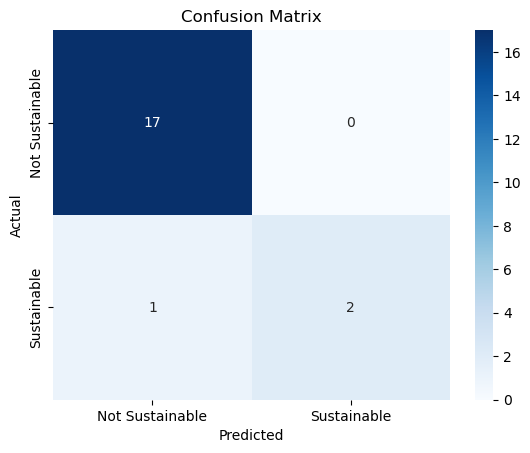

In [13]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Sustainable','Sustainable'],yticklabels=['Not Sustainable','Sustainable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [14]:
#Classification report
cr = classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       1.00      0.67      0.80         3

    accuracy                           0.95        20
   macro avg       0.97      0.83      0.89        20
weighted avg       0.95      0.95      0.95        20



In [15]:
#Feature Importance

coef = pd.DataFrame(model.coef_.T, index=X.columns, columns=['Coefficient'])
coef #print(coef)

,Coefficient
carbon_emissions,-0.023347
energy_output,0.001097
renewability_index,1.092184
cost_efficiency,-1.259560


In [16]:
#Saving the model

import joblib
joblib.dump(model,'Linear Regression Classification.pkl')

['Linear Regression Classification.pkl']

## Random Forest Algorithms

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
#load the dataset

data = pd.read_csv('agricultural sustainability.csv')
data.tail()

,soil_health,crop_yield,water_usage,carbon_footprint,fertilizer_use,sustainability
195,0.349210,9376.815930,2632.827381,442.455759,72.895518,0
196,0.725956,8725.714767,3504.009823,469.453227,279.328394,0
197,0.897110,4860.946246,1275.439420,304.309933,84.204658,0
198,0.887086,7757.839610,1365.300585,363.492871,287.559338,0
199,0.779876,7790.885867,683.908773,465.124722,161.501443,0


In [19]:
data.shape

(200, 6)

In [20]:
#Check the missing value

data.isnull().sum()

soil_health         0
crop_yield          0
water_usage         0
carbon_footprint    0
fertilizer_use      0
sustainability      0
dtype: int64

In [21]:
data.columns

Index(['soil_health', 'crop_yield', 'water_usage', 'carbon_footprint',
       'fertilizer_use', 'sustainability'],
      dtype='object')

In [22]:
#feature & Target Selection 

x=data[['soil_health', 'crop_yield', 'water_usage', 'carbon_footprint',
       'fertilizer_use']]
y= data['sustainability']

In [23]:
# Dataset Split 

xtr,xte,ytr,yte = train_test_split(
 x,y, train_size=0.8,random_state=12
)

In [24]:
#Model Instantiation

rf_model= RandomForestClassifier(
 n_estimators=100, random_state=42
)

In [25]:
#Train the model -fit
rf_model.fit(xtr,ytr)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
#Predict 

rf_pred = rf_model.predict(xte)
rf_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0])

In [27]:
rf_acc = accuracy_score(yte, rf_pred)
print(f'The Accuracy score is {rf_acc*100:.2f}%')

The Accuracy score is 100.00%


In [28]:
cm = confusion_matrix(yte,rf_pred)
cm

array([[35,  0],
       [ 0,  5]])

In [29]:
crrf = classification_report(yte, rf_pred)
print(crrf)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00         5

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [30]:
#Saving the model #Self Practice

import joblib
joblib.dump(model,'Random Forest Algorithms Classification.pkl')

['Random Forest Algorithms Classification.pkl']

## Unsupervised Learning

1. K Mean Clustering

In [31]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [32]:
#load the dataset

df1 = pd.read_csv('environmental factors.csv')
df1.head()

,temperature,humidity,wind_speed,carbon_emissions,solar_irradiance,pollution_level
0,22.490802,52.418449,19.599966,337.165056,369.020837,84.723658
1,34.014286,49.974726,8.690240,256.681604,185.335998,49.451704
2,29.639879,40.569235,11.932794,484.024336,213.723302,19.546561
3,26.973170,66.436000,18.265613,148.540303,262.604015,73.664179
4,18.120373,58.597450,14.641787,314.535387,283.288001,41.867814


In [33]:
#Scaling #Normalization & Standardization of dataset

scaler = StandardScaler() #instantiate the scaler

In [34]:
data_scaled = scaler.fit_transform(df1)
print(pd.DataFrame(data_scaled,
                   columns=df1.columns).head())

   temperature  humidity  wind_speed  carbon_emissions  solar_irradiance  \
0    -0.415900 -0.452465    0.801884          0.482494         -0.684316   
1     1.587377 -0.593258   -1.100359         -0.136414         -1.389866   
2     0.826917 -1.135149   -0.534981          1.611824         -1.280827   
3     0.363328  0.355146    0.569224         -0.968007         -1.093072   
4    -1.175669 -0.096466   -0.062635          0.308475         -1.013623   

   pollution_level  
0         1.193409  
1        -0.029923  
2        -1.067119  
3         0.809835  
4        -0.292954  


### Elbow Method (Error)

inertia = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

In [35]:
# ELBOW Method 
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10  # recommended to avoid warnings
    )
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)


#### Error in Inertia
plt.plot(k_range,inertia,marker='0')
plt.title('Elbow Method')
plt.xlabel('Number of Cluster(k)')
plt.ylabel('Inertia')
plt.show()

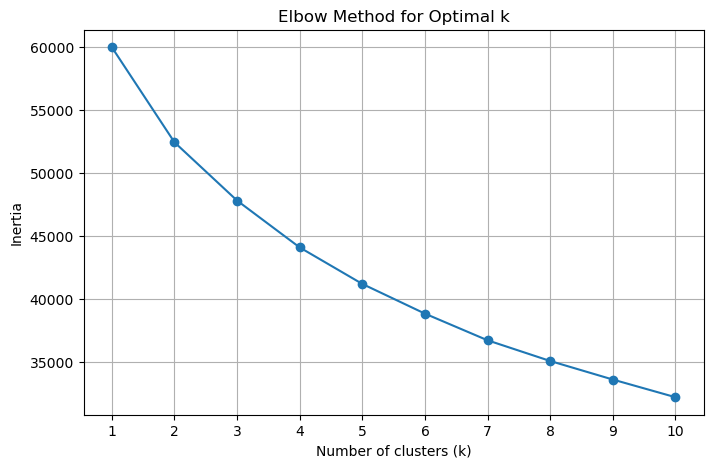

In [36]:
#plot the inertia


plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [37]:
k = 7
kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
df1['cluster'] = kmeans.fit_predict(data_scaled)
print(df1)

      temperature   humidity  wind_speed  carbon_emissions  solar_irradiance  \
0       22.490802  52.418449   19.599966        337.165056        369.020837   
1       34.014286  49.974726    8.690240        256.681604        185.335998   
2       29.639879  40.569235   11.932794        484.024336        213.723302   
3       26.973170  66.436000   18.265613        148.540303        262.604015   
4       18.120373  58.597450   14.641787        314.535387        283.288001   
...           ...        ...         ...               ...               ...   
9995    32.153120  82.622318   24.045509        389.315259        660.200681   
9996    32.950177  32.808837   19.956484        394.037121        303.574216   
9997    33.934158  48.221908    5.389117        171.306244        774.095576   
9998    22.949760  56.599200   13.020097        245.443897        568.909821   
9999    19.342808  40.335889   10.147960        269.340664        875.536039   

      pollution_level  cluster  
0     

In [38]:
# Evalution - Sil Score 

sil_score = silhouette_score(data_scaled, df1['cluster'])
sil_score

0.12516919892466188

<function matplotlib.pyplot.show(close=None, block=None)>

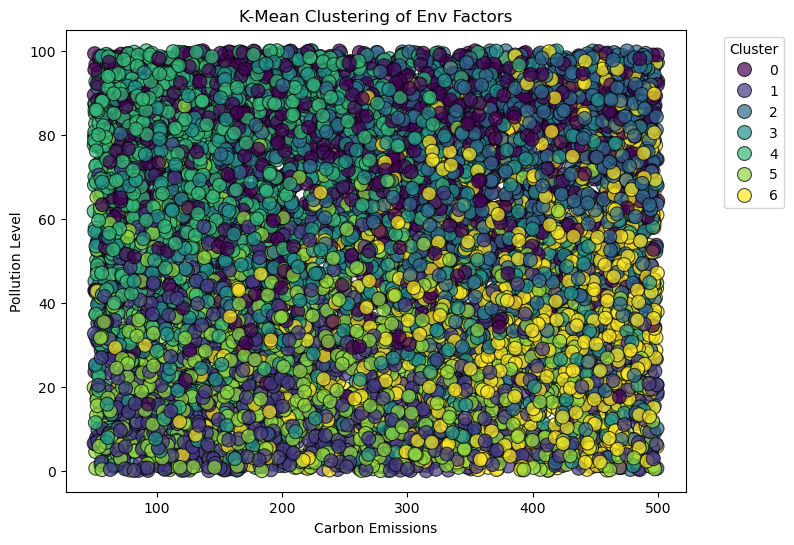

In [39]:
plt.figure(figsize=(8,6))
sns.scatterplot(
                x='carbon_emissions', y='pollution_level',
                hue='cluster',data=df1, palette='viridis',
                s=100, alpha=0.7, edgecolor='k'
               )

plt.title('K-Mean Clustering of Env Factors')
plt.xlabel('Carbon Emissions')
plt.ylabel('Pollution Level')
plt.legend(title='Cluster',bbox_to_anchor=(1.05,1), loc='upper left')
plt.show